### APP vs. C-APP: does the bag-generation protocol change which quantifier looks best?

This notebook analyzes the output of `scripts/compare_bag_protocols.py`, which evaluates the six quantifiers from the original CBMS'26 study (CC, PCC, ACC, PACC, EMQ, HDy), across four base classifiers (LR, SVM, GB, RF), under two bag-generation protocols on the **same** fitted quantifiers and the **same** held-out test patients:

- **APP** (Artificial Prevalence Protocol): each bag's target prevalence is drawn uniformly from the full [0, 1] simplex.
- **C-APP** (Clinically-Constrained APP): each bag's prevalence is drawn from clinically-defined risk bands per arrhythmia type (see `ecg_quantification.CLINICAL_RANGES`), then collapsed to a binary   "arrhythmic burden" for direct comparison with APP.

This directly answers the concern about the original CBMS'26 study: that APP explores an unconstrained, possibly clinically unrealistic prevalence range and removes any temporal/clinical structure from the evaluation.

**How to use this notebook**: run `scripts/compare_bag_protocols.py` first (see its own `--help` for options), then point `RESULTS_DIR` below at its `--output-dir`. Sections that need `detailed_results.csv` or `summary_table.csv` will print a short notice and skip their plot if those files aren't found, so the ranking-only sections still run even before the full run finishes.


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon

try:
  # keeps this notebook's palette consistent with every other figure in the
  # project (ecg_quantification.visualization._signal_window, etc.)
  from ecg_quantification.visualization import COLORBLIND_PALETTE
except ImportError:
  COLORBLIND_PALETTE = [
    '#0072B2', '#D55E00', '#009E73', '#CC79A7',
    '#E69F00', '#56B4E9', '#F0E442', '#000000',
  ]

plt.rcParams.update({
  'figure.dpi': 120,
  'savefig.dpi': 300,
  'font.size': 11,
  'axes.spines.top': False,
  'axes.spines.right': False,
  'axes.grid': True,
  'grid.alpha': 0.3,
})

NAIVE_METHODS = ['CC', 'PCC']          # no prior-probability-shift correction
CORRECTED_METHODS = ['ACC', 'PACC', 'EMQ', 'HDy']  # bias-corrected / distribution-matching

FIGURES_DIR = 'figures/app_vs_capp'
os.makedirs(FIGURES_DIR, exist_ok=True)


def savefig(fig, name):
  # Saves a figure as both PNG (quick preview) and PDF (vector, for LaTeX inclusion) under FIGURES_DIR.
  fig.tight_layout()
  for ext in ('png', 'pdf'):
    fig.savefig(os.path.join(FIGURES_DIR, f'{name}.{ext}'), bbox_inches='tight')


#### 1. Load results

Points at the three CSVs `compare_bag_protocols.py` writes to its `--output-dir`. Adjust `RESULTS_DIR` to wherever you ran it.

In [2]:
RESULTS_DIR = '../results/app_vs_capp'

def _try_load(filename):
  path = os.path.join(RESULTS_DIR, filename)
  if not os.path.exists(path):
    print(f"[not found] {path} -- run scripts/compare_bag_protocols.py first "
      f"(sections needing this file will be skipped below).")
    return None

  df = pd.read_csv(path)
  print(f"[loaded] {path}: {df.shape[0]} rows, {df.shape[1]} columns")

  return df


ranking_df = _try_load('ranking_comparison.csv')
summary_df = _try_load('summary_table.csv')
detailed_df = _try_load('detailed_results.csv')

if ranking_df is not None:
  ranking_df[['classifier', 'method']] = ranking_df['quantifier'].str.split('-', n=1, expand=True)

HAS_RANKING = ranking_df is not None
HAS_SUMMARY = summary_df is not None
HAS_DETAILED = detailed_df is not None

[loaded] ../results/app_vs_capp/ranking_comparison.csv: 72 rows, 5 columns
[loaded] ../results/app_vs_capp/summary_table.csv: 144 rows, 5 columns
[loaded] ../results/app_vs_capp/detailed_results.csv: 144000 rows, 7 columns


#### 2. Does the protocol change the ranking? (Spearman correlation)

A high correlation would suggest the protocol barely matters; a low one would suggest APP results don't generalize to a clinically realistic setting. In practice the answer turns out to be more nuanced than either extreme.

In [3]:
if HAS_RANKING:
  corr_rows = []
  for bag_size, group in ranking_df.groupby('bag_size'):
    corr, pvalue = spearmanr(group['app_rank'], group['capp_rank'])
    best_app = group.loc[group['app_rank'].idxmin(), 'quantifier']
    best_capp = group.loc[group['capp_rank'].idxmin(), 'quantifier']
    corr_rows.append({
      'bag_size': bag_size,
      'spearman_rho': round(corr, 3),
      'p_value': pvalue,
      'best_under_APP': best_app,
      'best_under_C-APP': best_capp,
      'same_best_quantifier': best_app == best_capp,
    })

  corr_table = pd.DataFrame(corr_rows)
  display(corr_table)
else:
  print("Skipped: ranking_comparison.csv not found.")


,bag_size,spearman_rho,p_value,best_under_APP,best_under_C-APP,same_best_quantifier
0,100,0.935,2.309181e-11,LR-EMQ,LR-HDy,False
1,200,0.945,3.563268e-12,LR-EMQ,LR-HDy,False
2,500,0.945,3.563268e-12,LR-EMQ,LR-HDy,False


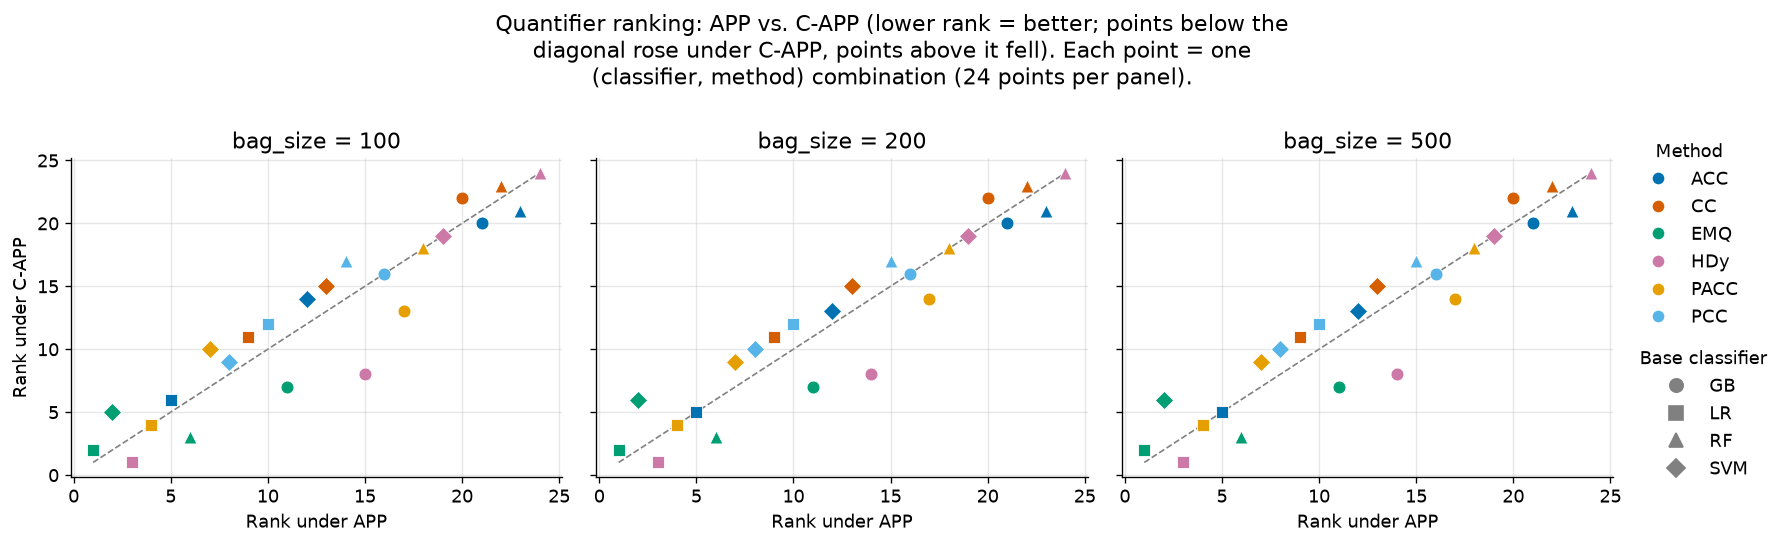

In [4]:
if HAS_RANKING:
  from matplotlib.lines import Line2D

  fig, axes = plt.subplots(1, ranking_df['bag_size'].nunique(), 
                           figsize=(5 * ranking_df['bag_size'].nunique(), 4.5), sharex=True, sharey=True)
  if ranking_df['bag_size'].nunique() == 1:
    axes = [axes]

  methods = sorted(ranking_df['method'].unique())
  classifiers = sorted(ranking_df['classifier'].unique())
  method_colors = {m: COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)] for i, m in enumerate(methods)}
  classifier_markers = {c: m for c, m in zip(classifiers, ['o', 's', '^', 'D', 'v', 'P'])}

  for ax, (bag_size, group) in zip(axes, ranking_df.groupby('bag_size')):
    n = group['app_rank'].max()
    ax.plot([1, n], [1, n], color='grey', linestyle='--', linewidth=1, zorder=1)
    for (method, classifier), sub in group.groupby(['method', 'classifier']):
      ax.scatter(sub['app_rank'], sub['capp_rank'],
                color=method_colors[method], marker=classifier_markers[classifier],
                s=60, zorder=2, edgecolor='white', linewidth=0.5)
    ax.set_title(f'bag_size = {bag_size}')
    ax.set_xlabel('Rank under APP')

  axes[0].set_ylabel('Rank under C-APP')

  # two separate legends: color -> method, marker shape -> base classifier
  method_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=method_colors[m],
                            markersize=8, label=m) for m in methods]
  classifier_handles = [Line2D([0], [0], marker=classifier_markers[c], color='grey', linestyle='',
                                markersize=8, label=c) for c in classifiers]

  legend1 = axes[-1].legend(handles=method_handles, title='Method', bbox_to_anchor=(1.02, 1.10),
                            loc='upper left', frameon=False)
  axes[-1].add_artist(legend1)
  axes[-1].legend(handles=classifier_handles, title='Base classifier', bbox_to_anchor=(1.02, 0.45),
                  loc='upper left', frameon=False)

  fig.suptitle('Quantifier ranking: APP vs. C-APP (lower rank = better; points below the\n'
               'diagonal rose under C-APP, points above it fell). Each point = one\n'
               '(classifier, method) combination (24 points per panel).', y=1.00)
  savefig(fig, '01_rank_scatter_app_vs_capp')
  plt.show()
else:
  print("Skipped: ranking_comparison.csv not found.")

#### 3. Where does the ranking move? Per-method and per-classifier shift

`rank_shift = app_rank - capp_rank`: positive means the quantifier rose (did relatively better) under C-APP.

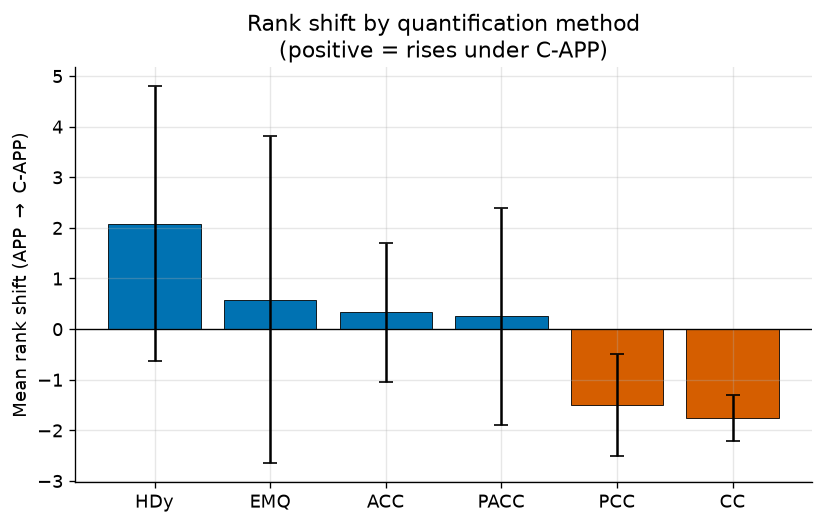

,mean,std
method,,
HDy,2.08,2.71
EMQ,0.58,3.23
ACC,0.33,1.37
PACC,0.25,2.14
PCC,-1.50,1.00
CC,-1.75,0.45


In [5]:
if HAS_RANKING:
  def shift_barplot(groupby_col, title, filename):
    agg = ranking_df.groupby(groupby_col)['rank_shift'].agg(['mean', 'std']).sort_values('mean', ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    colors = [COLORBLIND_PALETTE[0] if v >= 0 else COLORBLIND_PALETTE[1] for v in agg['mean']]
    ax.bar(agg.index, agg['mean'], yerr=agg['std'], capsize=4, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Mean rank shift (APP $\\rightarrow$ C-APP)')
    ax.set_title(title)
    savefig(fig, filename)
    plt.show()
    return agg

  method_shift = shift_barplot('method', 'Rank shift by quantification method\n(positive = rises under C-APP)',
                               '02_rank_shift_by_method')
  display(method_shift.round(2))
else:
  print("Skipped: ranking_comparison.csv not found.")


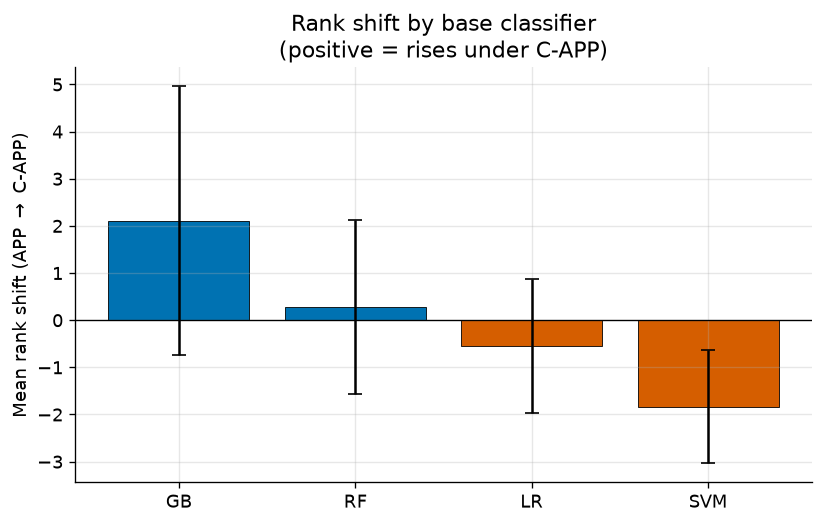

,mean,std
classifier,,
GB,2.11,2.85
RF,0.28,1.84
LR,-0.56,1.42
SVM,-1.83,1.20


In [6]:
if HAS_RANKING:
  classifier_shift = shift_barplot('classifier', 'Rank shift by base classifier\n(positive = rises under C-APP)',
                                    '03_rank_shift_by_classifier')
  display(classifier_shift.round(2))
else:
  print("Skipped: ranking_comparison.csv not found.")

#### 4. Statistical significance of the shift

Wilcoxon signed-rank test on `rank_shift`, comparing the two uncorrected methods (CC, PCC -- no prior-probability-shift adjustment) against the four bias-corrected distribution-matching methods (ACC, PACC, EMQ, HDy). The null hypothesis is that the median shift is zero (protocol doesn't systematically favor either group).

In [7]:
if HAS_RANKING:
  def wilcoxon_row(label, methods):
    shifts = ranking_df[ranking_df['method'].isin(methods)]['rank_shift']
    stat, pvalue = wilcoxon(shifts)
    return {
      'group': label,
      'methods': ', '.join(methods),
      'n': len(shifts),
      'mean_shift': round(shifts.mean(), 2),
      'wilcoxon_stat': stat,
      'p_value': pvalue,
    }

  significance_table = pd.DataFrame([
    wilcoxon_row('Naive (no PPS correction)', NAIVE_METHODS),
    wilcoxon_row('Bias-corrected', CORRECTED_METHODS),
  ])
  display(significance_table)
else:
  print("Skipped: ranking_comparison.csv not found.")


,group,methods,n,mean_shift,wilcoxon_stat,p_value
0,Naive (no PPS correction),"CC, PCC",24,-1.62,0.0,0.000022
1,Bias-corrected,"ACC, PACC, EMQ, HDy",48,0.81,173.0,0.032230


#### 5. Top-ranked quantifier per protocol, per bag size

In [8]:
if HAS_RANKING:
  for bag_size, group in ranking_df.groupby('bag_size'):
    print(f"--- bag_size = {bag_size} ---")
    top_app = group.nsmallest(5, 'app_rank')[['quantifier', 'app_rank', 'capp_rank']].rename(
       columns={'app_rank': 'rank'}).assign(protocol='APP')
    top_capp = group.nsmallest(5, 'capp_rank')[['quantifier', 'capp_rank', 'app_rank']].rename(
       columns={'capp_rank': 'rank'}).assign(protocol='C-APP')
    combined = pd.concat([top_app, top_capp])[['protocol', 'quantifier', 'rank']]
    display(combined.reset_index(drop=True))
else:
  print("Skipped: ranking_comparison.csv not found.")


--- bag_size = 100 ---


,protocol,quantifier,rank
0,APP,LR-EMQ,1
1,APP,SVM-EMQ,2
2,APP,LR-HDy,3
3,APP,LR-PACC,4
4,APP,LR-ACC,5
5,C-APP,LR-HDy,1
6,C-APP,LR-EMQ,2
7,C-APP,RF-EMQ,3
8,C-APP,LR-PACC,4
9,C-APP,SVM-EMQ,5


--- bag_size = 200 ---


,protocol,quantifier,rank
0,APP,LR-EMQ,1
1,APP,SVM-EMQ,2
2,APP,LR-HDy,3
3,APP,LR-PACC,4
4,APP,LR-ACC,5
5,C-APP,LR-HDy,1
6,C-APP,LR-EMQ,2
7,C-APP,RF-EMQ,3
8,C-APP,LR-PACC,4
9,C-APP,LR-ACC,5


--- bag_size = 500 ---


,protocol,quantifier,rank
0,APP,LR-EMQ,1
1,APP,SVM-EMQ,2
2,APP,LR-HDy,3
3,APP,LR-PACC,4
4,APP,LR-ACC,5
5,C-APP,LR-HDy,1
6,C-APP,LR-EMQ,2
7,C-APP,RF-EMQ,3
8,C-APP,LR-PACC,4
9,C-APP,LR-ACC,5


#### 6. Error magnitude by protocol

Rank shift shows *direction* but not *magnitude*. This section uses `detailed_results.csv` (per-bag absolute error) to check whether the naive-methods' rank drop under C-APP corresponds to a small or a large increase in actual MAE.

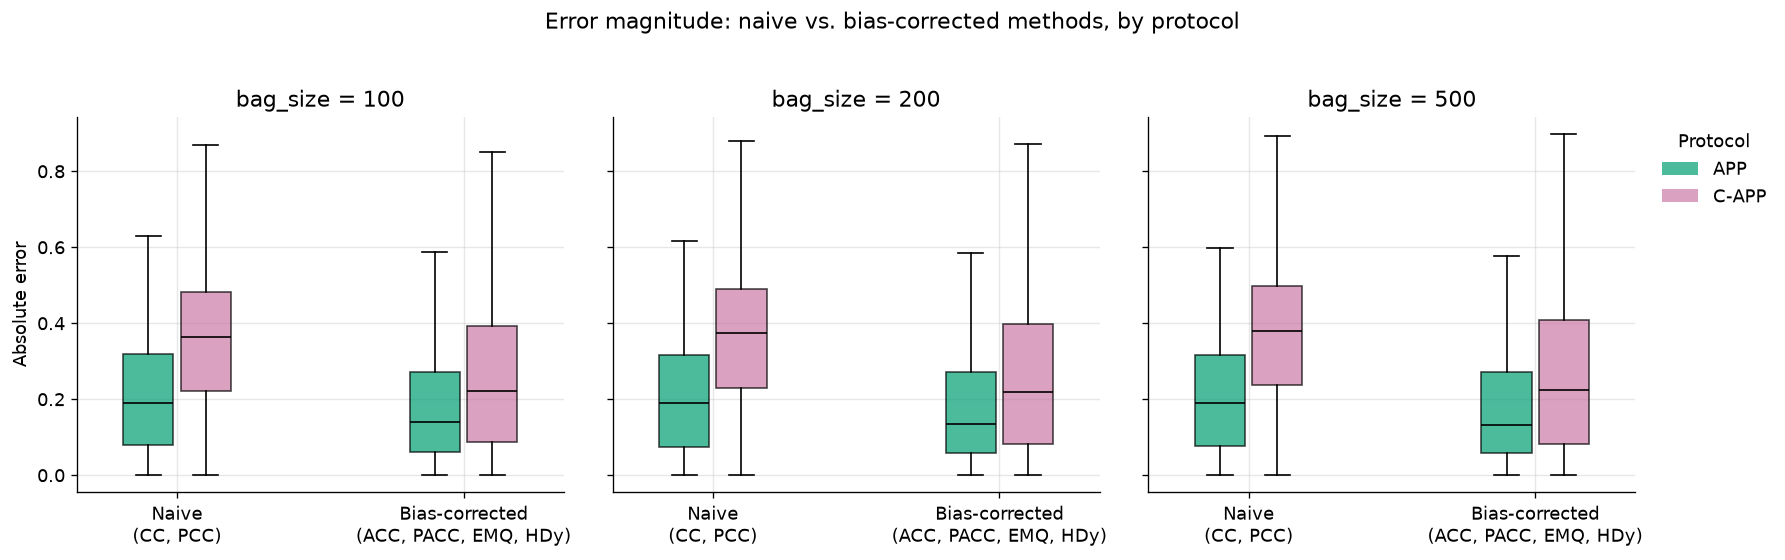

In [9]:
if HAS_DETAILED:
  detailed_df[['classifier', 'method']] = detailed_df['quantifier'].str.split('-', n=1, expand=True)
  detailed_df['method_group'] = np.where(
    detailed_df['method'].isin(NAIVE_METHODS), 'Naive\n(CC, PCC)', 'Bias-corrected\n(ACC, PACC, EMQ, HDy)'
  )

  # color always means "protocol" here (never method group, never classifier)
  # -- consistent, single-meaning color mapping with a real legend, rather
  # than 4 arbitrary palette colors for 4 boxes with no legend at all.
  # Colors deliberately different from the blue/vermillion "rises/falls"
  # convention used in Section 3's bar charts, so the same colors don't
  # accidentally suggest a good/bad reading in a plot where they mean
  # something else entirely.
  protocol_colors = {'APP': COLORBLIND_PALETTE[2], 'C-APP': COLORBLIND_PALETTE[3]}  # bluish green / reddish purple
  method_groups = ['Naive\n(CC, PCC)', 'Bias-corrected\n(ACC, PACC, EMQ, HDy)']
  protocols = ['APP', 'C-APP']
  box_width = 0.35

  fig, axes = plt.subplots(1, detailed_df['bag_size'].nunique(), figsize=(5 * detailed_df['bag_size'].nunique(), 4.5), sharey=True)
  if detailed_df['bag_size'].nunique() == 1:
    axes = [axes]

  for ax, (bag_size, group) in zip(axes, detailed_df.groupby('bag_size')):
    group_centers = np.arange(len(method_groups)) * 2.0
    for p_idx, protocol in enumerate(protocols):
      offset = (p_idx - 0.5) * (box_width + 0.05)
      positions = group_centers + offset
      data = [group[(group['method_group'] == mg) & (group['protocol'] == protocol)]['abs_error']
              for mg in method_groups]
      bp = ax.boxplot(data, positions=positions, widths=box_width, patch_artist=True, showfliers=False)
      for patch in bp['boxes']:
        patch.set_facecolor(protocol_colors[protocol])
        patch.set_alpha(0.7)
      for median in bp['medians']:
        median.set_color('black')

    ax.set_xticks(group_centers)
    ax.set_xticklabels(method_groups)
    ax.set_title(f'bag_size = {bag_size}')

  axes[0].set_ylabel('Absolute error')

  legend_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=protocol_colors[p], alpha=0.7, label=p) for p in protocols]
  axes[-1].legend(handles=legend_handles, title='Protocol', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

  fig.suptitle('Error magnitude: naive vs. bias-corrected methods, by protocol', y=1.03)
  savefig(fig, '04_error_magnitude_by_protocol')
  plt.show()
else:
  print("Skipped: detailed_results.csv not found - run compare_bag_protocols.py to generate it.")


#### 7. Where do errors concentrate? Binned calibration curve

A raw scatter of every bag's (true, predicted) burden, thousands of points pooled across quantifiers and bag sizes, turns into an undifferentiated cloud that hides the one thing this plot is meant to show: **systematic** prior-probability-shift bias. A calibration curve fixes this the same way Fig. 4/5 of the CBMS'26 paper avoided plotting every raw prediction: true burden is binned, and each bin's predicted burden is summarized as mean $\pm$ 1 SD, split by method group (naive vs. bias-corrected) and protocol.

Perfect predictions fall on the diagonal. A curve that systematically bows away from it (e.g. compressing toward the training prevalence at the extremes) is the classic signature of prior-probability shift, exactly what quantification-adjustment methods are meant to correct, and exactly what should differ between the two protocols' error profiles if C-APP's narrower, clinically realistic prevalence range changes how that bias manifests.

Aggregated across bag sizes (bias is a property of the quantifier and the protocol's prevalence range, not of a single bag_size; faceting by both method_group and bag_size here would split the data past the point of being readable). Bins with fewer than 5 bags are dropped rather than plotted with a misleadingly narrow band.

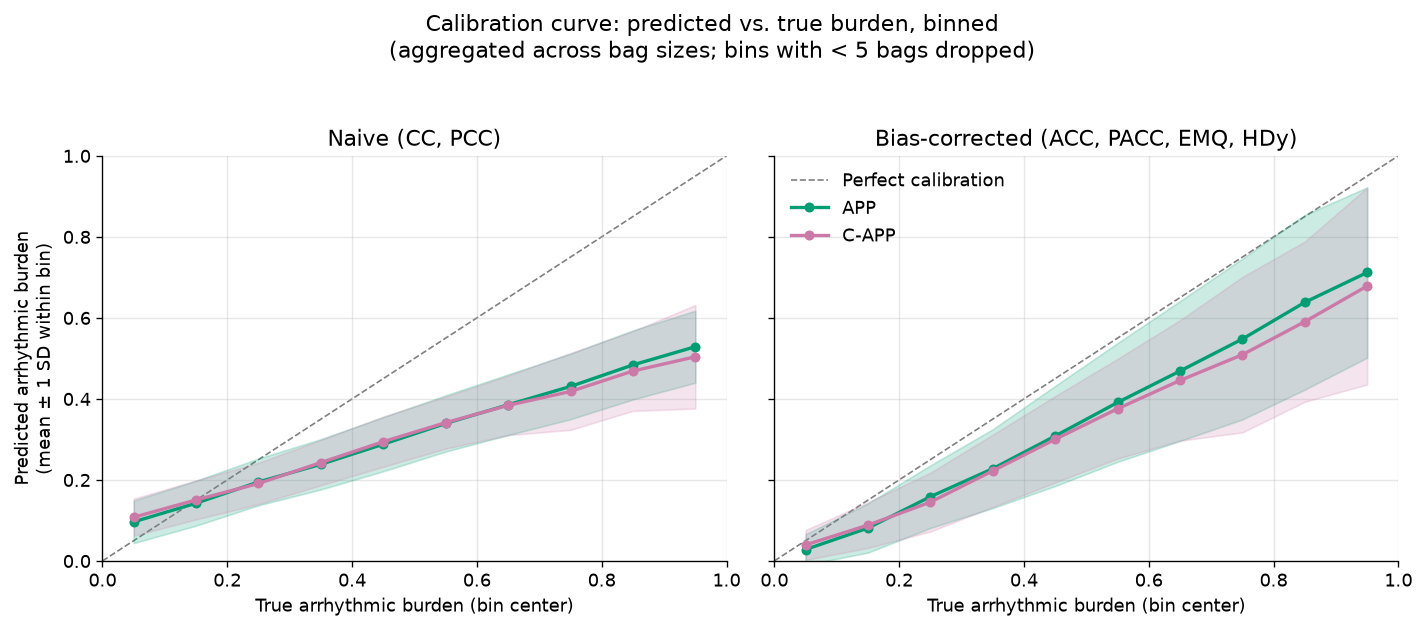

In [ ]:
if HAS_DETAILED:
  detailed_df[['classifier', 'method']] = detailed_df['quantifier'].str.split('-', n=1, expand=True)
  detailed_df['method_group'] = np.where(
    detailed_df['method'].isin(NAIVE_METHODS), 'Naive (CC, PCC)', 'Bias-corrected (ACC, PACC, EMQ, HDy)'
  )

  N_BINS = 10
  bin_edges = np.linspace(0, 1, N_BINS + 1)
  bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
  detailed_df['true_bin'] = pd.cut(detailed_df['true_burden'], bins=bin_edges, include_lowest=True, labels=False)

  method_groups = ['Naive (CC, PCC)', 'Bias-corrected (ACC, PACC, EMQ, HDy)']
  protocol_colors = {'APP': COLORBLIND_PALETTE[2], 'C-APP': COLORBLIND_PALETTE[3]}
  MIN_BAGS_PER_BIN = 5

  fig, axes = plt.subplots(1, len(method_groups), figsize=(6 * len(method_groups), 5), sharex=True, sharey=True)

  for ax, method_group in zip(axes, method_groups):
    ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, zorder=1, label='Perfect calibration')

    for protocol in ['APP', 'C-APP']:
      subset = detailed_df[(detailed_df['method_group'] == method_group) & (detailed_df['protocol'] == protocol)]
      binned = subset.groupby('true_bin')['pred_burden'].agg(['mean', 'std', 'count'])
      binned = binned[binned['count'] >= MIN_BAGS_PER_BIN]

      x = bin_centers[binned.index.astype(int)]
      y = binned['mean'].values
      yerr = binned['std'].values

      color = protocol_colors[protocol]
      ax.plot(x, y, color=color, marker='o', markersize=5, linewidth=2, label=protocol, zorder=3)
      ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2, zorder=2)

    ax.set_title(method_group)
    ax.set_xlabel('True arrhythmic burden (bin center)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

  axes[0].set_ylabel('Predicted arrhythmic burden\n(mean $\\pm$ 1 SD within bin)')
  axes[-1].legend(loc='upper left', frameon=False)

  fig.suptitle('Calibration curve: predicted vs. true burden, binned\n'
                '(aggregated across bag sizes; bins with < 5 bags dropped)', y=1.04)
  savefig(fig, '05_calibration_app_vs_capp')
  plt.show()
else:
  print("Skipped: detailed_results.csv not found -- run compare_bag_protocols.py to generate it.")
